# 1. О ПРОЕКТЕ И ПОСТАНОВКЕ ЗАДАЧИ

**Цель:** Развертывание и оптимизация модели YOLOv8 для автоматического поиска дефектов ткани на мобильных и edge-устройствах.

### Суть задачи
Необходимо создать систему компьютерного зрения, которая способна находить промышленный брак на тканях прямо в процессе производства в реальном времени.

Главное условие — нейросеть должна работать на устройствах с ограниченной вычислительной мощностью (например, на смартфонах или недорогих встраиваемых платах, установленных на конвейере). Поэтому для проекта выбрана самая легкая и быстрая архитектура в линейке — **YOLOv8 Nano**.



# 2. ПОДГОТОВКА СРЕДЫ И ИМПОРТ БИБЛИОТЕК

Установка необходимых фреймворков и подготовка окружения (Ultralytics для работы с YOLOv8 и Roboflow для загрузки датасета).


In [ ]:
!pip install -q ultralytics roboflow  # Установка библиотек YOLO и Roboflow


In [ ]:
import os             # Работа с файловой системой
import cv2            # Компьютерное зрение (OpenCV)
import glob           # Поиск файлов по шаблонам
import random         # Генерация случайных чисел
import numpy as np    # Матричные вычисления
import pandas as pd   # Работа с таблицами
import matplotlib.pyplot as plt    # Отрисовка графиков и фото
import plotly.express as px        # Интерактивная визуализация
from tqdm.notebook import tqdm     # Полоса загрузки (Progress bar)
from ultralytics import YOLO       # Модели YOLO (v8+)
from roboflow import Roboflow      # Загрузка датасетов
from google.colab.patches import cv2_imshow   # Вывод фото в Colab
from getpass import getpass        # Безопасный ввод (пароли/ключи)
from IPython.display import HTML   # Вставка HTML (для видео)
from base64 import b64encode       # Кодирование видео

# 3. АРХИТЕКТУРА МОДЕЛИ И МЕТРИКИ ОЦЕНКИ

### Краткое описание проблемы
Детекция дефектов ткани требует высокой точности на мелких объектах и способности работать в реальном времени на производственных линиях или мобильных терминалах контроля качества. Основной вызов заключается в ограничении вычислительных ресурсов мобильных устройств, что делает невозможным использование тяжелых моделей.

### Основные концепции
Для оптимизации и работы в условиях ограниченных ресурсов выбрана архитектура **YOLOv8**, обладающая следующими преимуществами:
* **One-Stage Detection:** Предсказание рамок (bounding boxes) и классов за один проход нейросети, что обеспечивает максимальную скорость.
* **Anchor-Free:** Отказ от заранее заданных якорных боксов снижает вычислительную нагрузку и упрощает архитектуру.
* **Model Scaling:** Использование облегченной версии **Nano** (минимизация параметров) обеспечивает баланс между точностью детекции и скоростью работы на мобильных CPU/GPU.

### Математическое обоснование метрик

Основной метрикой в задачах детекции объектов является **Intersection over Union (IoU)**. Она используется как для обучения (в функциях потерь Loss functions), так и для оценки точности локализации дефектов.

$$IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$

Где:
* **Area of Overlap:** Площадь пересечения предсказанного и истинного ограничивающего бокса.
* **Area of Union:** Общая площадь, занимаемая обоими боксами.

Для оценки итоговой точности модели по всем классам и порогам IoU используется метрика **mAP (Mean Average Precision)**.

### Схема архитектуры

Ниже представлена общая схема архитектуры YOLOv8. Версия **Nano** сохраняет эту структуру, но имеет минимальные коэффициенты глубины слоев (`depth`) и ширины каналов (`width`). Это снижает вычислительную нагрузку и делает модель оптимальной для edge-устройств. Детекция объектов происходит в режиме **Anchor-free**.


 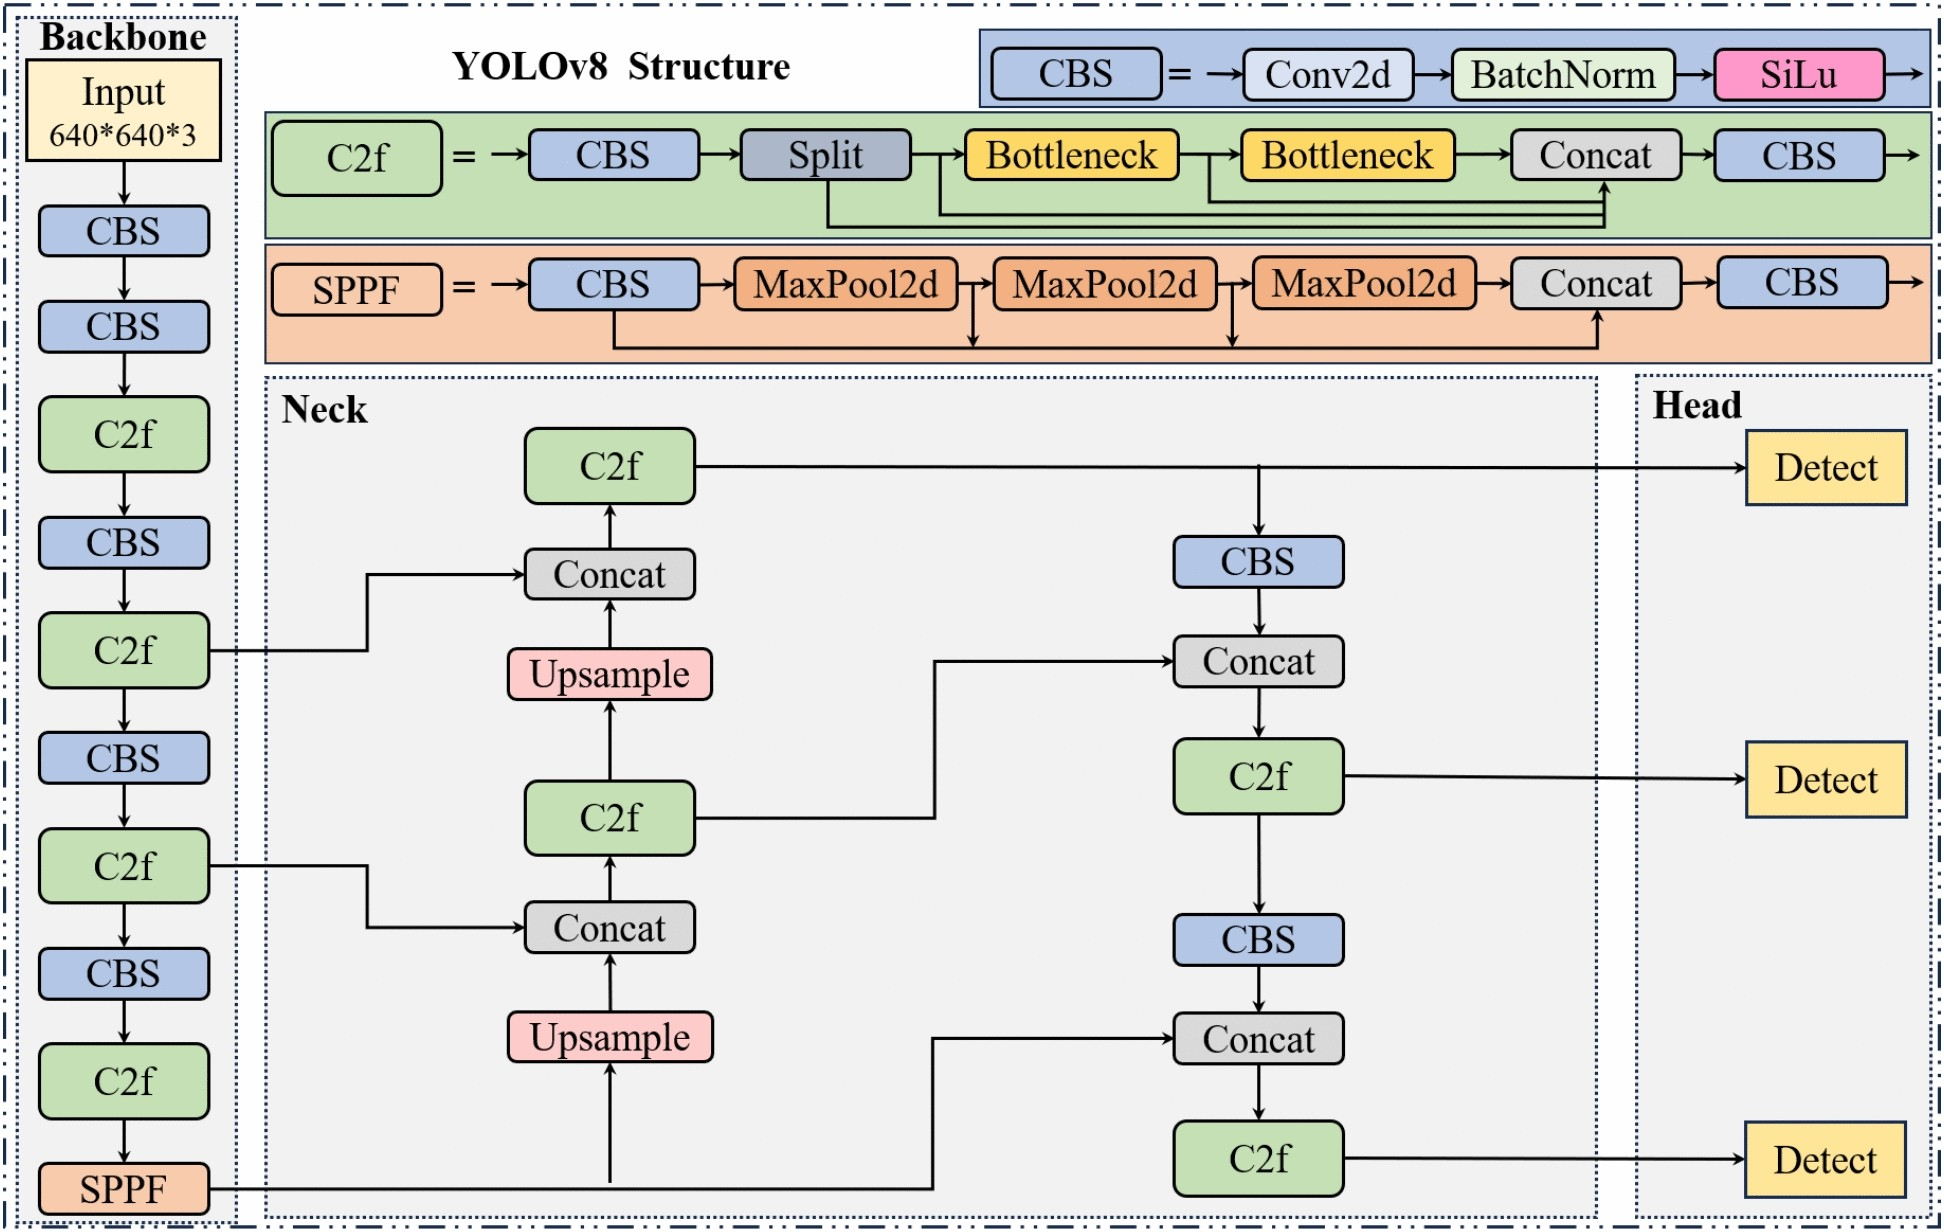


## 4. ПОДГОТОВКА ДАННЫХ
На этом этапе осуществляется аутентификация в сервисе Roboflow, загрузка датасета "Fabric Defect" и анализ структуры данных.


In [ ]:
api_key = getpass('Roboflow API Key: ')  # Запрос ключа доступа (скрытый ввод)
rf = Roboflow(api_key=api_key)           # Инициализация клиента Roboflow


Roboflow API Key: ··········


### 4.1 Загрузка и структурирование датасета
Скачиваем датасет с платформы Roboflow Universe. Импорт выполняется напрямую в формате YOLOv8, который включает в себя:
* Изображения в формате `.jpg`
* Файлы аннотаций `.txt` (в формате: class_id, x_center, y_center, width, height)
* Конфигурационный файл `data.yaml`, описывающий пути к выборкам и названия классов.


In [ ]:
project = rf.workspace("fabric-defect-zpkfr").project("fabric-defect-fvlhp")
version = project.version(2)
dataset = version.download("yolov8")  # Скачивание данных в формате YOLOv8

DATA_YAML = os.path.join(dataset.location, "data.yaml") # Путь к конфигурационному файлу

loading Roboflow workspace...
loading Roboflow project...


### 4.2 Предобработка данных
Библиотека **Ultralytics** выполняет предобработку изображений автоматически "под капотом". Процесс включает в себя:
*   **Ресайз:** Приведение всех изображений к единому размеру (640x640).
*   **Нормализация:** Масштабирование яркости пикселей в диапазон [0, 1] для ускорения сходимости обучения.
*   **Аугментация:** Применение методов *Mosaic* и *MixUp* в процессе обучения для повышения устойчивости модели к дефектам разного масштаба.

In [ ]:
print("Содержимое датасета:")
for split in ['train', 'valid', 'test']:   # Проход по папкам (обучение, валидация, тест)
    images_count = len(glob.glob(os.path.join(dataset.location, split, 'images', '*.jpg')))  # Подсчет JPG-файлов
    print(f" {split}: {images_count} изображений")  # Вывод количества фото в каждой папке

Содержимое датасета:
 train: 1530 изображений
 valid: 195 изображений
 test: 191 изображений


### 4.3 Визуализация примеров
Выведем случайное изображение из обучающей выборки, чтобы убедиться в корректности загрузки данных.


Размер оригинала: (640, 640)


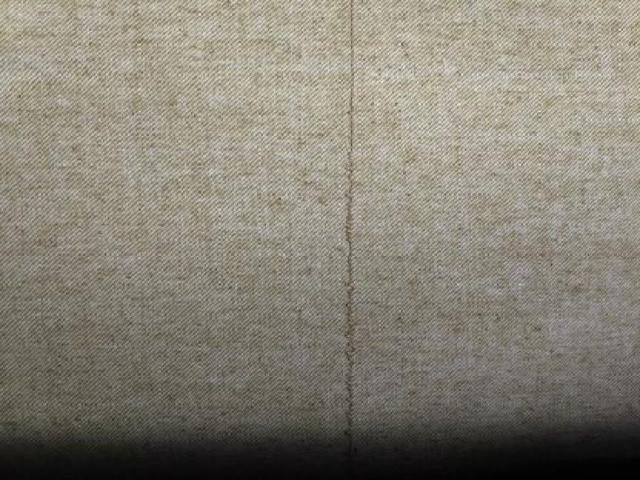

In [ ]:

train_images = glob.glob(os.path.join(dataset.location, 'train', 'images', '*.jpg'))
random_img = random.choice(train_images)  # Выбор случайного изображения

img = cv2.imread(random_img)              # Чтение картинки через OpenCV
print(f"Размер оригинала: {img.shape[:2]}") # Вывод разрешения (высота, ширина)
cv2_imshow(cv2.resize(img, (640, 480)))


# 5. НАСТРОЙКА И ИНИЦИАЛИЗАЦИЯ МОДЕЛИ

Для проекта выбрана модель **YOLOv8 Nano (yolov8n)**. Это самая маленькая и легкая нейросеть в семействе YOLO. Она идеально подходит для запуска на обычных смартфонах или слабых компьютерах, установленных прямо на производстве, так как весит мало и не перегружает память устройства.

**Как работает эта модель:**
* **Она быстрая:** YOLO — это One-Stage детектор. Ей достаточно одного взгляда на картинку, чтобы сразу найти дефект и определить его тип. Это позволяет обрабатывать видео в реальном времени.
* **Делает две задачи сразу:** Нейросеть одновременно учится двум вещам — правильно находить координаты брака (рисовать рамку) и точно угадывать, что это за дефект.
* **Главный показатель:** Качество мы оцениваем по метрике **mAP@50**. Она просто показывает, насколько хорошо рамки модели совпали с реальным браком на ткани.



In [ ]:
# @title 5.1 Настройка гиперпараметров и инициализация модели { display-mode: "form" }

# Определение гиперпараметров (требование: Настройка гиперпараметров)
EPOCHS = 45 # @param {type:"slider", min:10, max:100, step:5}
IMG_SIZE = 640 # @param {type:"integer"}
BATCH_SIZE = 16 # @param {type:"integer"}

model = YOLO('yolov8n.pt')

# 6. ОБУЧЕНИЕ МОДЕЛИ

Мы запускаем процесс тонкой настройки (Fine-tuning) на основе предобученных весов. Это позволяет нейросети быстрее адаптироваться к специфическим текстурам ткани и особенностям дефектов.

В процессе обучения модель минимизирует три основные функции потерь:
1. **box_loss** — ошибка координат рамки дефекта.
2. **cls_loss** — ошибка определения класса (типа брака).
3. **dfl_loss** — ошибка точности и распределения границ объекта.




In [ ]:
results = model.train(
    data=DATA_YAML, # Путь к файлу конфигурации данных
    epochs=EPOCHS,  # Количество эпох обучения
    imgsz=IMG_SIZE, # Размер входных изображений
    batch=BATCH_SIZE, # Размер батча
    device=0,         # Использование GPU (0)
    name='fabric_defect_v8', # Название папки с результатами
    plots=True               # Генерация графиков обучения
)


# 7. ОЦЕНКА РЕЗУЛЬТАТОВ




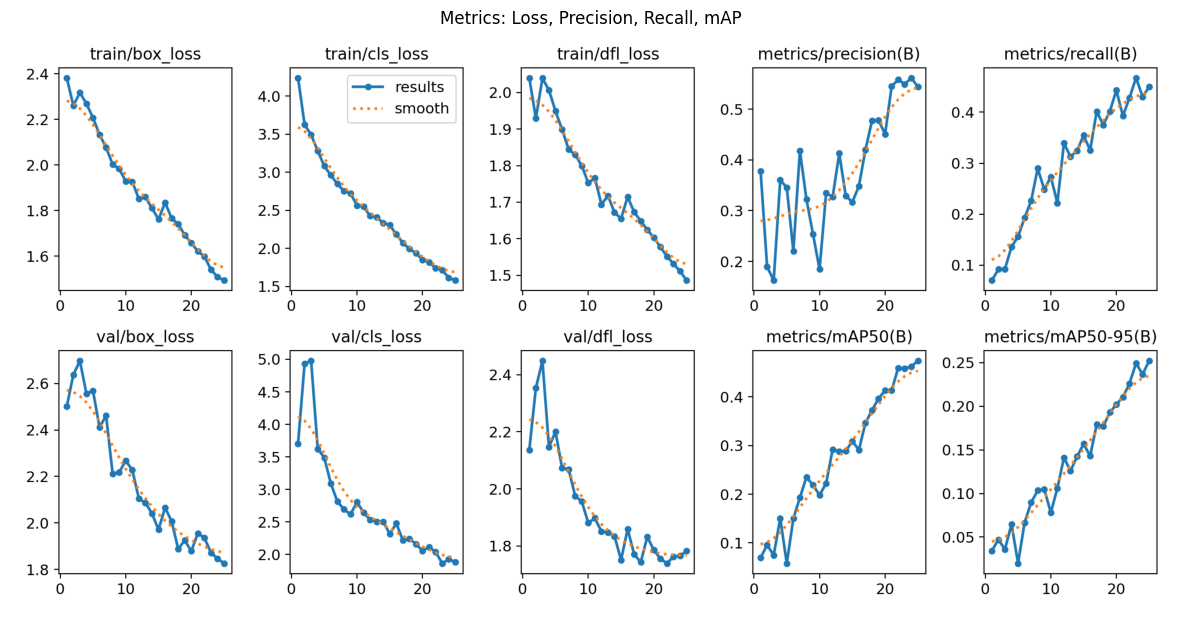

In [ ]:
results_path = 'runs/detect/fabric_defect_v8'

plt.figure(figsize=(15, 10))
results_img = cv2.imread(f'{results_path}/results.png')
plt.imshow(cv2.cvtColor(results_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Metrics: Loss, Precision, Recall, mAP")
plt.show()

**Анализ графиков обучения:**
*   Кривые потерь (Loss) для обучения и валидации плавно снижаются. Это говорит о том, что процесс обучения идет правильно, и модель не переобучается (нет резкого расхождения графиков `train` и `val`).
*   Точность (mAP50) и полнота (Recall) уверенно растут. К 25-й эпохе модель вышла на стабильные показатели, успешно научившись распознавать основные признаки дефектов.
*   **Итог:** Модель стабильна и готова к тестированию на реальных изображениях.


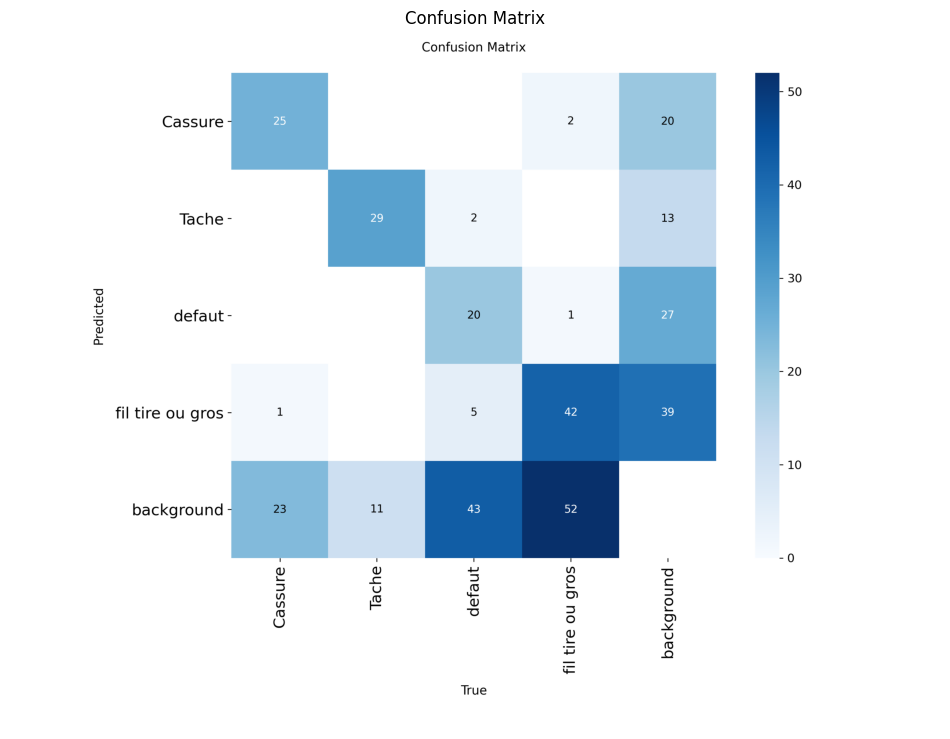

In [ ]:
plt.figure(figsize=(12, 10))
cm_img = cv2.imread(f'{results_path}/confusion_matrix.png')
plt.imshow(cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Confusion Matrix")
plt.show()

**Анализ матрицы ошибок:**
*  Модель лучше всего определяет дефекты типов `fil tire ou gros` и `Tache`. По диагонали видно, что большая часть предсказаний для них верна. Много реальных дефектов модель пропускает (False Negatives), принимая их за чистую ткань. Также есть ложные срабатывания на пустых участках.
*  Причиной этому служит то, что ткань имеет сложную текстуру, и некоторые дефекты очень мелкие или бледные, из-за чего нейросети Nano-версии сложно отличить их от структуры нитей.


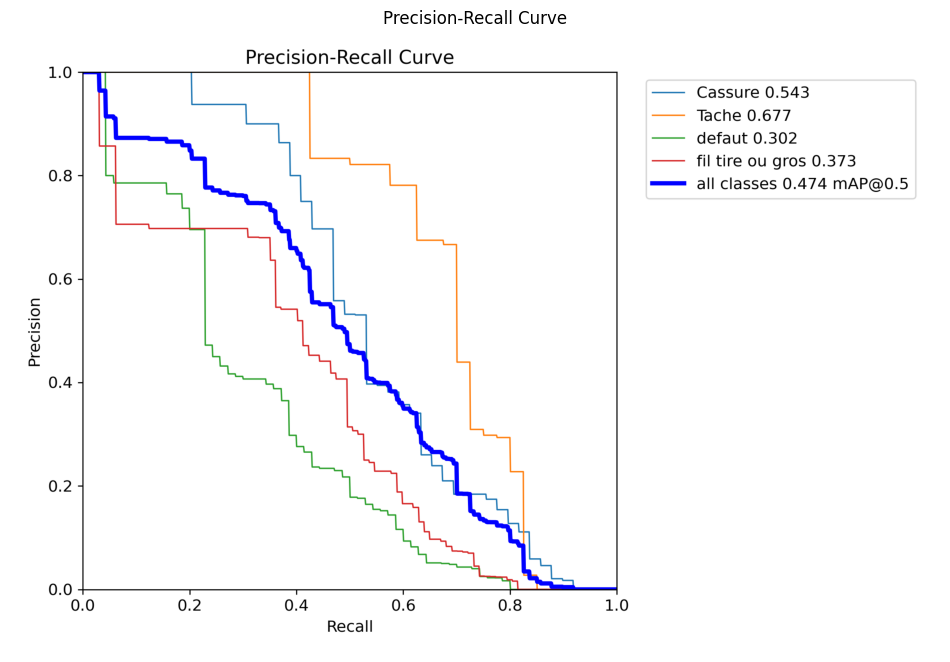

In [ ]:
plt.figure(figsize=(12, 10))
pr_img = cv2.imread(f'{results_path}/BoxPR_curve.png')
plt.imshow(cv2.cvtColor(pr_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Precision-Recall Curve")
plt.show()


**Анализ PR-кривой:**
*   График подтверждает, что лучше всего модель выучила класс `Tache` (оранжевая линия, mAP=0.677) — это самые заметные дефекты.
*  Класс `defaut` (зеленая линия, mAP=0.302) дается модели труднее всего, вероятно, из-за нехватки примеров или слабой выраженности признаков.
*   **Общий итог:** Средний показатель по всем классам составляет **0.474**, что является достойным результатом для компактной Nano-модели на сложном производстве.


### Визуализация предсказаний
Для финальной проверки запустим модель на изображениях из тестовой выборки, которые она не видела в процессе обучения. Это позволит оценить реальную применимость модели.


image 1/1 /content/fabric-defect--2/test/images/147_jpg.rf.285389c5dd054f1d55d3b2f6213a7fa0.jpg: 640x640 1 defaut, 1 fil tire ou gros, 10.2ms
Speed: 2.0ms preprocess, 10.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/fabric-defect--2/test/images/Camera-HT-SUA630C-0002-0001-Snapshot-20210114135456-5232118828449_JPG_jpg.rf.366df672187f9390c1e0e8a04dc5de2f.jpg: 640x640 2 defauts, 1 fil tire ou gros, 7.2ms
Speed: 1.5ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/fabric-defect--2/test/images/Camera-HT-SUA630C-0002-0001-Snapshot-20210102155842-1498128736609_JPG_jpg.rf.3c4afd0758e7e75a174d4cf3ed0a42cb.jpg: 640x640 1 fil tire ou gros, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/fabric-defect--2/test/images/191-1-_jpg.rf.3116d26603e2d5875f75c5a1f536f844.jpg: 640x640 1 Tache, 7.2ms
Speed: 1.4ms preprocess, 7.2ms infere

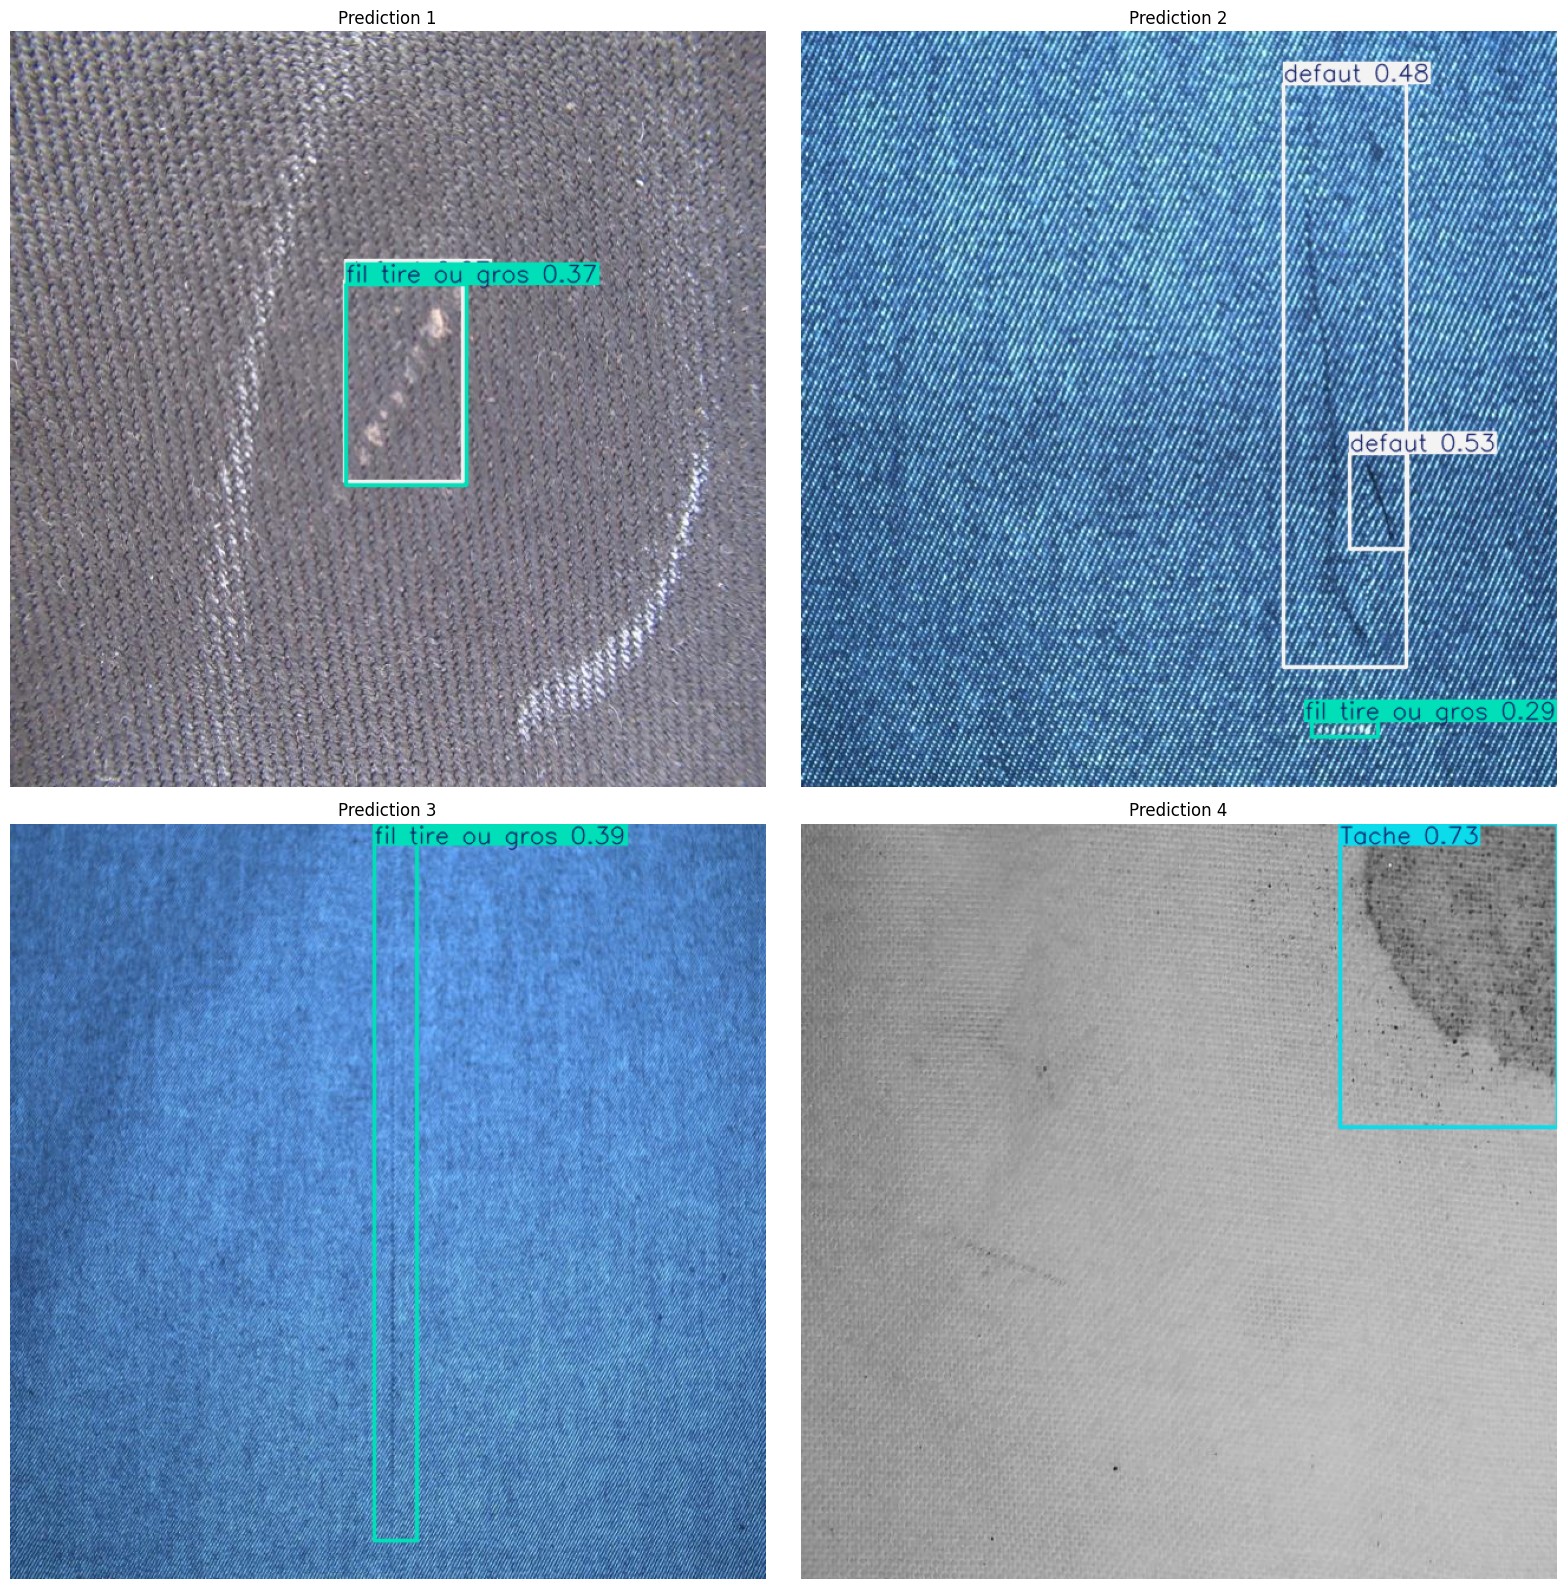

In [ ]:
best_model = YOLO(f'{results_path}/weights/best.pt')  # Загрузка обученных весов
test_images = glob.glob(f"{dataset.location}/test/images/*.jpg")  # Список тестовых фото
sample_images = random.sample(test_images, 4)                     # Выбор 4-х случайных примеров
fig, axes = plt.subplots(2, 2, figsize=(16, 16))                  # Сетка для вывода 2x2
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    res = best_model.predict(img_path, conf=0.25)[0]
    res_img = res.plot()
    axes[i].imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Prediction {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Практический анализ инференса

Визуализация предсказаний показывает, что модель успешно справляется с локализацией брака. Крупные пятна и контрастные дефекты структуры нейросеть определяет стабильно и с высокой уверенностью.

С мелкими зацепками и тонкими нитями Nano-версии работать сложнее: иногда рамка захватывает лишнюю область чистой ткани вокруг дефекта. Однако, учитывая минимальный размер архитектуры (**YOLOv8 Nano**), такой компромисс полностью оправдан. Модель обеспечивает высокую скорость обработки (минимальный инференс в миллисекундах) и надежно фиксирует критические дефекты, чего достаточно для контроля качества в реальном времени.




## Видео-демонстрация работы модели

Для симуляции работы системы в реальном времени тестовые последовательные кадры объединены в единый видеопоток. Этот шаг имитирует видеопоток с реальной камеры, установленной над конвейерной лентой на производстве.

Такой подход позволяет наглядно оценить:
* Скорость детекции объектов (инференс на потоке кадров).
* Стабильность удержания рамок (bounding boxes) на дефектах при смене ракурсов и движении ткани.



In [ ]:

test_images = sorted(glob.glob(f"{dataset.location}/test/images/*.jpg"))[:30]  # Берем первые 30 фото тестовой папки
video_name = 'smart_detection.mp4'   # Имя выходного файла
fps = 2                              # Скорость смены кадров

frame = cv2.imread(test_images[0])   # Чтение первого кадра для параметров
h, w, _ = frame.shape                # Получение размеров видео
video = cv2.VideoWriter(video_name, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h)) # Создание видеофайла

for image_path in tqdm(test_images):
    raw_img = cv2.imread(image_path)   # Чтение исходного фото
    video.write(raw_img)

    res = best_model.predict(image_path, conf=0.25, verbose=False)   # Детекция дефектов
    video.write(res[0].plot())

video.release()  # Сохранение и закрытие видеофайла




In [ ]:
!ffmpeg -y -i smart_detection.mp4 -vcodec libx264 -f mp4 final_smart_video.mp4 # Перекодировка видео для браузера

mp4 = open('final_smart_video.mp4','rb').read()               # Чтение итогового файла
data_url = "data:video/mp4;base64," + b64encode(mp4).decode() # Кодирование в Base64 для плеера
HTML(f'<video width=800 controls autoplay loop><source src="{data_url}" type="video/mp4"></video>') # Вывод видео в Colab




# 8. ИТОГИ И ВЫВОДЫ

Выполнено дообучение (**fine-tuning**) модели **YOLOv8 Nano** на специализированном датасете. Выбранная архитектура отлично подходит для мобильных и edge-устройств.

**Основные итоги:**
1. **Скорость и легкость:** Вес модели составляет всего **6.2 МБ**, а инференс занимает считанные миллисекунды. Это наглядно подтверждается финальным видео — детекция идет плавно и без задержек.
2. **Эффективность дообучения:** Видео-демонстрация на тестовой выборке показала, что процесс fine-tuning прошел успешно — нейросеть стабильно находит дефекты (пятна, зацепки) на новых данных.
3. **Готовность к развертыванию:** Создано рабочее компактное решение, которое можно интегрировать на смартфон или встраиваемую систему автоматизации производства.

**Трудности и что можно улучшить:**
* Главная проблема — пропуски мелких и бледных дефектов. При дообучении Nano-версии мы осознанно жертвуем детализацией ради колоссальной скорости работы нейросети.
* В будущем стоит расширить датасет фотографиями при разном освещении и добавить «фоновые» снимки без брака, чтобы снизить количество ложных срабатываний и сделать работу модели на видео еще стабильнее.

### Полезные ссылки и источники:
*   **Архитектура модели:** [Ultralytics YOLOv8 Docs](https://docs.ultralytics.com/models/yolov8/) — официальная документация и описание структуры нейросети.
*   **Источник данных:** [Roboflow Universe](https://universe.roboflow.com/fabric-defect-zpkfr/fabric-defect-fvlhp/dataset/2) — платформа, с которой был загружен датасет дефектов ткани.
